In [4]:
# !pip -q install transformers torch pandas numpy scikit-learn matplotlib seaborn

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import GPT2Tokenizer, GPT2Model
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## GPT-2 model

In [7]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2").to(device)
model.eval()

embedding_matrix = model.get_input_embeddings().weight.detach()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Every token is represented by a 768-dimensional vector

In [8]:
embedding_matrix.shape

torch.Size([50257, 768])

In [9]:
def get_token_id(number):
    """
    Return token ID if the number is represented by exactly
    one GPT-2 token. Otherwise return None.
    """
    token_ids = tokenizer.encode(str(number), add_special_tokens=False)

    if len(token_ids) == 1:
        return token_ids[0]

    return None

In [10]:
numbers = list(range(0, 101))

single_token_numbers = []

for n in numbers:
    token_id = get_token_id(n)

    if token_id is not None:
        single_token_numbers.append(n)

print("Single-token numbers:")
print(single_token_numbers)

print("\nCount:", len(single_token_numbers))

Single-token numbers:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]

Count: 101


In [11]:
# GPT-2's vocabulary does not guarantee that every number is represented as one token.
tokenizer.encode(str(100000), add_special_tokens=False)

[3064, 830]

## Number to embedding mapping

In [12]:
number_to_token = {}
number_to_embedding = {}

for n in single_token_numbers:
    token_id = get_token_id(n)

    number_to_token[n] = token_id
    number_to_embedding[n] = embedding_matrix[token_id]

print("Number of usable numbers:", len(number_to_embedding))

Number of usable numbers: 101


Cosine similarity helper

In [13]:
def cosine_sim(v1, v2):
    v1 = v1.detach().cpu().numpy().reshape(1, -1)
    v2 = v2.detach().cpu().numpy().reshape(1, -1)

    return cosine_similarity(v1, v2)[0, 0]

In [14]:
def nearest_number(vector, candidate_numbers):
    """
    Find the number whose embedding has maximum cosine similarity
    with the supplied vector.
    """

    candidates = torch.stack([number_to_embedding[n] for n in candidate_numbers])

    vector = vector.unsqueeze(0)

    similarities = torch.nn.functional.cosine_similarity(vector, candidates, dim=1)

    best_idx = torch.argmax(similarities).item()

    return candidate_numbers[best_idx], similarities[best_idx].item()

In [15]:
nums = [4, 7, 9]
candidates = torch.stack([number_to_embedding[n] for n in nums])
candidates.shape

torch.Size([3, 768])

## Addition of Vectors

In [16]:
candidate_numbers = [n for n in single_token_numbers if 0 <= n <= 100]

results_add = []

for a in candidate_numbers:
    for b in candidate_numbers:

        # 4 + 7 = 11
        true_result = a + b

        if true_result not in number_to_embedding:
            continue

        va = number_to_embedding[a]
        vb = number_to_embedding[b]

        # vector(4) + vector(7)
        predicted_vector = va + vb

        # number most nearest to the vector: vector(4) + vector(7)
        predicted_number, similarity = nearest_number(predicted_vector, candidate_numbers)

        # cosine silimarity between vector(4) + vector(7) and vector(11)
        true_similarity = cosine_sim(predicted_vector, number_to_embedding[true_result])

        results_add.append({
            "a": a,
            "b": b,
            "actual": true_result,
            "predicted": predicted_number,
            "correct": predicted_number == true_result,
            "cosine_true": true_similarity,
            "cosine_predicted": similarity
        })

add_df = pd.DataFrame(results_add)

In [17]:
add_df.head(10)

,a,b,actual,predicted,correct,cosine_true,cosine_predicted
0,0,0,0,0,True,1.000000,1.000000
1,0,1,1,0,False,0.912400,0.924718
2,0,2,2,0,False,0.897810,0.914721
3,0,3,3,0,False,0.895320,0.909202
4,0,4,4,0,False,0.892296,0.907885
5,0,5,5,0,False,0.899278,0.912589
6,0,6,6,0,False,0.889730,0.904636
7,0,7,7,0,False,0.887123,0.899284
8,0,8,8,0,False,0.892165,0.904900
9,0,9,9,0,False,0.892393,0.899618


In [18]:
add_df.tail()

,a,b,actual,predicted,correct,cosine_true,cosine_predicted
5146,98,1,99,98,False,0.693583,0.848717
5147,98,2,100,98,False,0.556688,0.858672
5148,99,0,99,99,True,0.848182,0.848182
5149,99,1,100,99,False,0.586146,0.857833
5150,100,0,100,100,True,0.853699,0.853699


In [19]:
addition_accuracy = add_df["correct"].mean()

print(f"Addition accuracy: {addition_accuracy:.4f}")
print(f"Number of experiments: {len(add_df)}")
print(
    f"Mean cosine similarity to true answer: "
    f"{add_df['cosine_true'].mean():.4f}"
)

Addition accuracy: 0.0161
Number of experiments: 5151
Mean cosine similarity to true answer: 0.6815


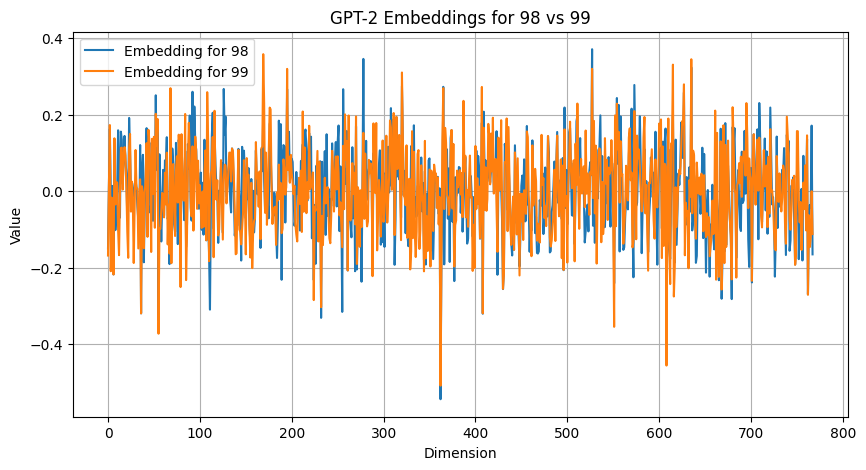

Cosine similarity between embedding of 98 and 99: 0.7349


In [20]:
e98 = number_to_embedding[98].cpu().numpy()
e99 = number_to_embedding[99].cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(e98, label="Embedding for 98")
plt.plot(e99, label="Embedding for 99")
plt.title("GPT-2 Embeddings for 98 vs 99")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

similarity_98_99 = cosine_sim(number_to_embedding[98], number_to_embedding[99])
print(f"Cosine similarity between embedding of 98 and 99: {similarity_98_99:.4f}")

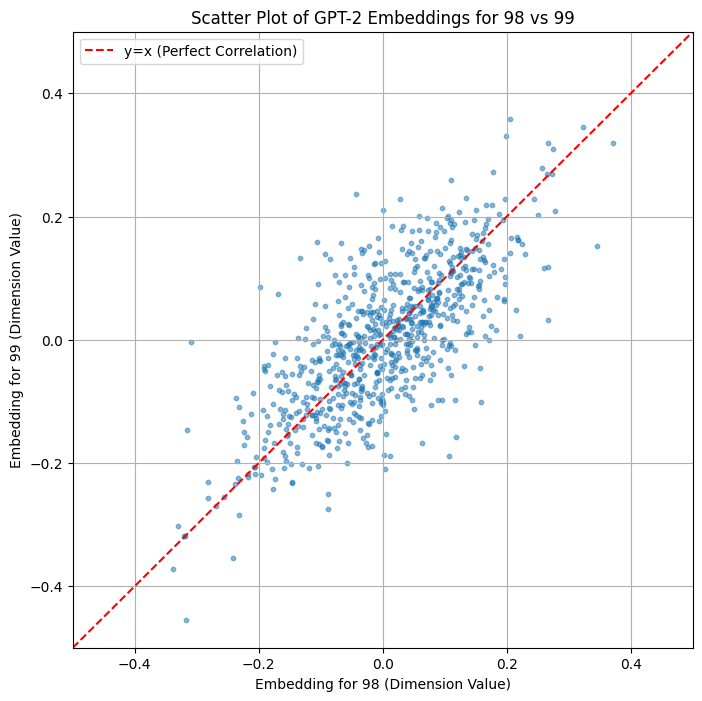

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(e98, e99, alpha=0.5, s=10) # s=10 for smaller points, alpha for overlap visibility
plt.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', label='y=x (Perfect Correlation)') # Add a diagonal line for reference
plt.title('Scatter Plot of GPT-2 Embeddings for 98 vs 99')
plt.xlabel('Embedding for 98 (Dimension Value)')
plt.ylabel('Embedding for 99 (Dimension Value)')
plt.xlim(-0.5, 0.5) # Set limits for better visualization
plt.ylim(-0.5, 0.5)
plt.grid(True)
plt.legend()
plt.show()

High cosine similarity does not necessarily mean arithmetic structure.

GPT-2's token embeddings are not distributed uniformly around the origin.

Many token embeddings (like for 99 and 98 here) can have a common directional component.

When you calculate:

$$ E(a)+E(b) $$

you're adding two vectors that may already point somewhat toward a common region.

That can produce a vector that has high cosine similarity with many number embeddings, regardless of whether \(a+b\) is correct.

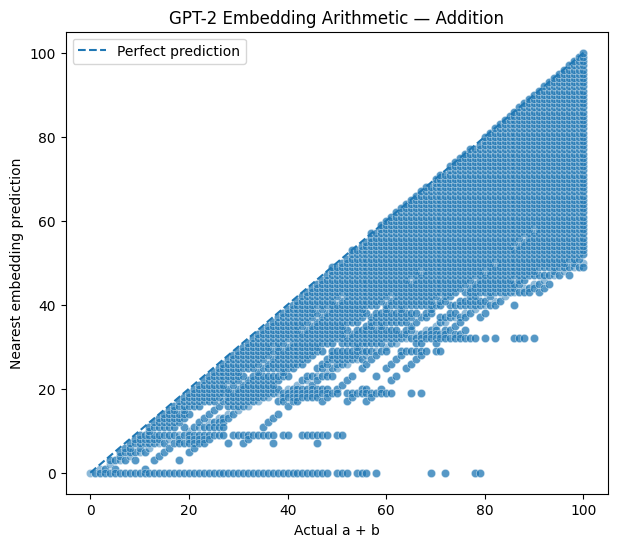

In [22]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=add_df,
    x="actual",
    y="predicted",
    alpha=0.5
)

plt.plot(
    [add_df.actual.min(), add_df.actual.max()],
    [add_df.actual.min(), add_df.actual.max()],
    "--",
    label="Perfect prediction"
)

plt.xlabel("Actual a + b")
plt.ylabel("Nearest embedding prediction")
plt.title("GPT-2 Embedding Arithmetic — Addition")

plt.legend()
plt.show()

## Subtraction of Vectors

In [23]:
results_sub = []

for a in candidate_numbers:
    for b in candidate_numbers:

        true_result = a - b

        if true_result not in number_to_embedding:
            continue

        va = number_to_embedding[a]
        vb = number_to_embedding[b]

        predicted_vector = va - vb

        predicted_number, similarity = nearest_number(predicted_vector, candidate_numbers)

        true_similarity = cosine_sim(predicted_vector, number_to_embedding[true_result])

        results_sub.append({
            "a": a,
            "b": b,
            "actual": true_result,
            "predicted": predicted_number,
            "correct": predicted_number == true_result,
            "cosine_true": true_similarity,
            "cosine_predicted": similarity
        })

sub_df = pd.DataFrame(results_sub)

In [24]:
sub_df.head()

,a,b,actual,predicted,correct,cosine_true,cosine_predicted
0,0,0,0,0,True,0.000000,0.000000
1,1,0,1,1,True,0.316424,0.316424
2,1,1,0,0,True,0.000000,0.000000
3,2,0,2,2,True,0.337262,0.337262
4,2,1,1,2,False,-0.316753,0.275294


In [25]:
sub_df.tail()

,a,b,actual,predicted,correct,cosine_true,cosine_predicted
5146,100,96,4,100,False,-0.050658,0.488573
5147,100,97,3,100,False,-0.046330,0.500389
5148,100,98,2,100,False,0.011930,0.486155
5149,100,99,1,100,False,0.057954,0.469389
5150,100,100,0,0,True,0.000000,0.000000


In [26]:
print("Subtraction accuracy:",
      sub_df["correct"].mean())

print("Mean cosine:",
      sub_df["cosine_true"].mean())

Subtraction accuracy: 0.039021549213744906
Mean cosine: 0.04098833


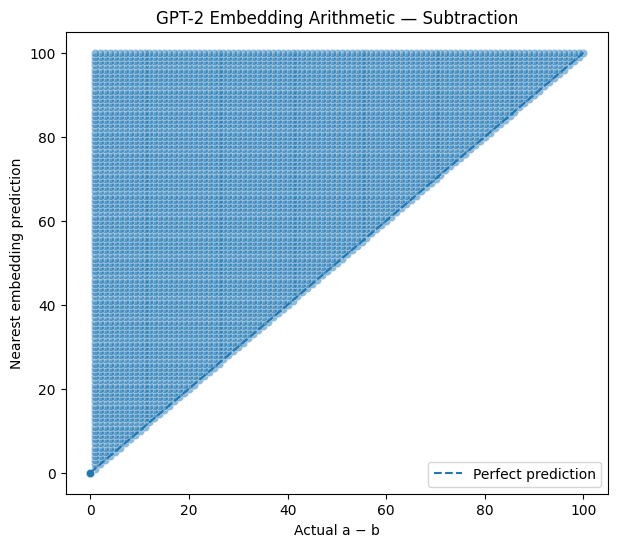

In [27]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=sub_df,
    x="actual",
    y="predicted",
    alpha=0.5
)

plt.plot(
    [sub_df.actual.min(), sub_df.actual.max()],
    [sub_df.actual.min(), sub_df.actual.max()],
    "--",
    label="Perfect prediction"
)

plt.xlabel("Actual a − b")
plt.ylabel("Nearest embedding prediction")
plt.title("GPT-2 Embedding Arithmetic — Subtraction")

plt.legend()
plt.show()

## Multiplication of Vectors

element-wise operations

In [28]:
results_mul = []

for a in candidate_numbers:
    for b in candidate_numbers:

        true_result = a * b

        if true_result not in number_to_embedding:
            continue

        va = number_to_embedding[a]
        vb = number_to_embedding[b]

        predicted_vector = va * vb

        predicted_number, similarity = nearest_number(
            predicted_vector,
            candidate_numbers
        )

        true_similarity = cosine_sim(
            predicted_vector,
            number_to_embedding[true_result]
        )

        results_mul.append({
            "a": a,
            "b": b,
            "actual": true_result,
            "predicted": predicted_number,
            "correct": predicted_number == true_result,
            "cosine_true": true_similarity,
            "cosine_predicted": similarity
        })

mul_df = pd.DataFrame(results_mul)

print("Experiments:", len(mul_df))

Experiments: 683


In [29]:
if len(mul_df):
    print("Accuracy:", mul_df["correct"].mean())
    print("Mean cosine:", mul_df["cosine_true"].mean())

Accuracy: 0.008784773060029283
Mean cosine: -0.12889135


## Division of Vectors

In [30]:
results_div = []

for a in candidate_numbers:
    for b in candidate_numbers:

        if b == 0:
            continue

        if a % b != 0:
            continue

        true_result = a // b

        if true_result not in number_to_embedding:
            continue

        va = number_to_embedding[a]
        vb = number_to_embedding[b]

        # Avoid numerical instability
        predicted_vector = va / (vb + 1e-8)

        predicted_number, similarity = nearest_number(
            predicted_vector,
            candidate_numbers
        )

        true_similarity = cosine_sim(
            predicted_vector,
            number_to_embedding[true_result]
        )

        results_div.append({
            "a": a,
            "b": b,
            "actual": true_result,
            "predicted": predicted_number,
            "correct": predicted_number == true_result,
            "cosine_true": true_similarity,
            "cosine_predicted": similarity
        })

div_df = pd.DataFrame(results_div)

In [31]:
print("Experiments:", len(div_df))

if len(div_df):
    print("Accuracy:", div_df["correct"].mean())
    print("Mean cosine:", div_df["cosine_true"].mean())

Experiments: 582
Accuracy: 0.020618556701030927
Mean cosine: 0.008448903


## Randomized control

In [32]:
rng = np.random.default_rng(42)

shuffled_numbers = candidate_numbers.copy()
rng.shuffle(shuffled_numbers)

random_embedding = {n: number_to_embedding[s] for n, s in zip(candidate_numbers, shuffled_numbers)}

In [34]:
print(candidate_numbers)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [35]:
print(shuffled_numbers)

[59, 21, 56, 18, 33, 42, 50, 27, 92, 71, 2, 25, 24, 52, 81, 100, 51, 61, 4, 98, 94, 37, 28, 80, 7, 57, 79, 26, 76, 78, 38, 0, 86, 46, 10, 29, 70, 45, 17, 39, 91, 40, 89, 5, 68, 1, 95, 84, 63, 3, 83, 93, 20, 87, 43, 73, 32, 75, 23, 96, 69, 15, 48, 55, 60, 9, 62, 31, 72, 16, 44, 82, 67, 34, 30, 58, 74, 88, 99, 54, 49, 6, 90, 11, 85, 41, 22, 19, 35, 64, 47, 12, 53, 14, 13, 66, 36, 97, 65, 77, 8]


In [36]:
control_results = []

for a in candidate_numbers:
    for b in candidate_numbers:

        true_result = a + b

        if true_result not in random_embedding:
            continue

        va = random_embedding[a]
        vb = random_embedding[b]

        predicted_vector = va + vb

        candidates = torch.stack([random_embedding[n] for n in candidate_numbers])

        similarities = torch.nn.functional.cosine_similarity(
            predicted_vector.unsqueeze(0),
            candidates,
            dim=1
        )

        idx = torch.argmax(similarities).item()

        predicted_number = candidate_numbers[idx]

        control_results.append({
            "actual": true_result,
            "predicted": predicted_number,
            "correct": predicted_number == true_result
        })

control_df = pd.DataFrame(control_results)

print("Randomized control accuracy:",control_df["correct"].mean())

Randomized control accuracy: 0.0083478936128907


In [37]:
print("Real embedding accuracy:",
      add_df["correct"].mean())

print("Randomized accuracy:",
      control_df["correct"].mean())

Real embedding accuracy: 0.016113376043486703
Randomized accuracy: 0.0083478936128907


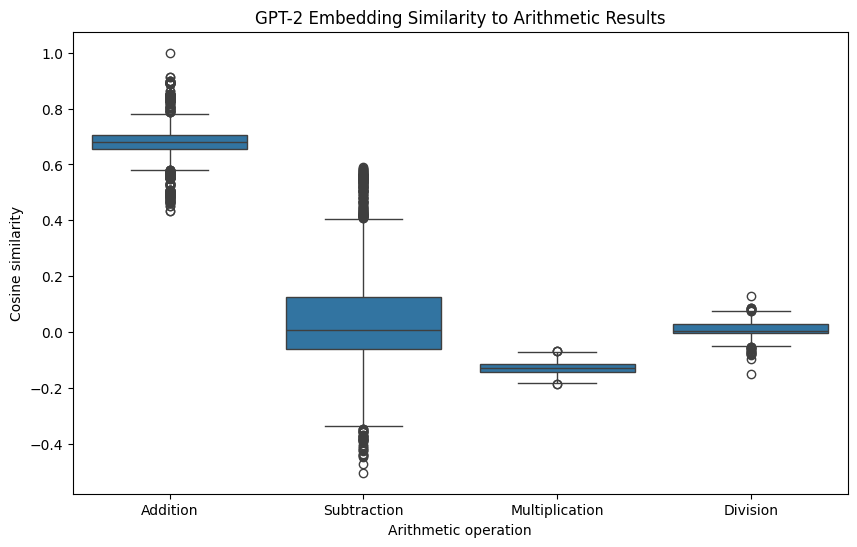

In [38]:
similarity_data = []

for name, df in [
    ("Addition", add_df),
    ("Subtraction", sub_df),
    ("Multiplication", mul_df),
    ("Division", div_df)
]:

    if len(df) == 0:
        continue

    for value in df["cosine_true"]:
        similarity_data.append({
            "operation": name,
            "cosine_similarity": value
        })

similarity_df = pd.DataFrame(similarity_data)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=similarity_df,
    x="operation",
    y="cosine_similarity"
)

plt.title(
    "GPT-2 Embedding Similarity to Arithmetic Results"
)

plt.xlabel("Arithmetic operation")
plt.ylabel("Cosine similarity")

plt.show()

In [39]:
summary = []

for name, df in [
    ("Addition", add_df),
    ("Subtraction", sub_df),
    ("Multiplication", mul_df),
    ("Division", div_df)
]:

    if len(df) == 0:
        continue

    summary.append({
        "Operation": name,
        "Experiments": len(df),
        "Accuracy": df["correct"].mean(),
        "Mean Cosine": df["cosine_true"].mean(),
        "Median Cosine": df["cosine_true"].median()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Operation,Experiments,Accuracy,Mean Cosine,Median Cosine
0,Addition,5151,0.016113,0.681549,0.680304
1,Subtraction,5151,0.039022,0.040988,0.006261
2,Multiplication,683,0.008785,-0.128891,-0.130045
3,Division,582,0.020619,0.008449,0.004666
